# Codebook-FIGS Tabular Benchmark Suite

This notebook demonstrates the **Codebook-FIGS Tabular Benchmark Suite** dataset builder. The pipeline:

1. Loads tabular datasets from **sklearn** and **OpenML**
2. Preprocesses features (one-hot encoding for categoricals, NaN handling)
3. Generates **5-fold stratified cross-validation splits** (seed=42)
4. Creates compact **mini versions** (≤200 samples each)
5. Validates all outputs (feature dimensions, NaN/inf checks, fold coverage)

The suite covers **classification and regression** tasks across domains including cardiology, diabetes, oncology, finance, housing, and chemistry.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, scikit-learn — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import sys
import traceback
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import (
    fetch_california_housing,
    fetch_openml,
    load_breast_cancer,
    load_diabetes,
)
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

## Load Pre-built Demo Data

Load a curated subset (50 examples from the breast cancer WDBC dataset) to inspect the output format.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/dataset_iter1_codebook_figs_t/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data["datasets"]:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  breast_cancer_wdbc: 50 examples


## Configuration

Tunable parameters for the dataset generation pipeline. These control which datasets are loaded and how CV splits and mini versions are created.

In [5]:
# --- Configuration ---
RANDOM_STATE = 42
N_SPLITS = 5            # Number of CV folds
MAX_MINI_SAMPLES = 200  # Max samples in mini version

# Number of datasets to process (1 = minimum, 10 = full suite)
N_DATASETS = 10

## Helper Functions

Core utilities for cross-validation fold generation, mini dataset sampling, one-hot encoding, and dataset group construction.

In [6]:
def assign_fold_labels(n_samples: int, folds: list[dict]) -> np.ndarray:
    """Map each sample to the fold index where it appears as a TEST sample."""
    labels = np.full(n_samples, -1, dtype=int)
    for fold_idx, fold in enumerate(folds):
        for idx in fold["test"]:
            labels[idx] = fold_idx
    assert np.all(labels >= 0), "Some samples not assigned to any fold"
    return labels


def generate_cv_folds(X, y, task_type: str, n_splits: int = N_SPLITS):
    if task_type == "classification":
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        return [{"train": tr.tolist(), "test": te.tolist()} for tr, te in splitter.split(X, y)]
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        return [{"train": tr.tolist(), "test": te.tolist()} for tr, te in splitter.split(X)]


def create_mini_indices(X, y, task_type: str, max_samples: int = MAX_MINI_SAMPLES):
    n = len(y)
    if n <= max_samples:
        return np.arange(n)
    if task_type == "classification":
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples, random_state=RANDOM_STATE)
        indices, _ = next(sss.split(X, y))
        return np.sort(indices)
    else:
        rng = np.random.RandomState(RANDOM_STATE)
        indices = rng.choice(n, size=max_samples, replace=False)
        return np.sort(indices)


def one_hot_encode(df: pd.DataFrame, cat_cols: list[str]):
    """One-hot encode categorical columns → (numpy array, feature_name list)."""
    result_cols, result_names = [], []
    for col in df.columns:
        if col in cat_cols:
            categories = sorted(df[col].dropna().unique())
            for cat in categories:
                result_cols.append((df[col] == cat).astype(float).values)
                clean = str(cat).replace(" ", "_").replace("'", "")
                result_names.append(f"{col}_{clean}")
        else:
            result_cols.append(pd.to_numeric(df[col], errors="coerce").values.astype(float))
            result_names.append(col)
    X = np.column_stack(result_cols) if result_cols else np.empty((len(df), 0))
    return X, result_names

## Dataset Group Builder and Validator

Functions to assemble one dataset group entry (with per-example input/output/metadata) and validate it for correctness.

In [7]:
def build_dataset_group(
    dataset_id: str,
    X: np.ndarray,
    y: np.ndarray,
    task_type: str,
    n_classes: int | None,
    domain: str,
    domain_description: str,
    source: str,
    feature_names: list[str],
    original_feature_names: list[str],
    feature_descriptions: dict | None,
    is_mini: bool = False,
    parent_indices: np.ndarray | None = None,
):
    """Build one dataset group entry (one element of the top-level 'datasets' array)."""
    n_samples, n_features = X.shape
    folds = generate_cv_folds(X, y, task_type)
    fold_labels = assign_fold_labels(n_samples, folds)

    did = dataset_id + ("_mini" if is_mini else "")

    examples = []
    for i in range(n_samples):
        input_vec = X[i].tolist()
        output_val = str(int(y[i])) if task_type == "classification" else str(float(y[i]))
        row_index = int(parent_indices[i]) if parent_indices is not None else i

        ex = {
            "input": json.dumps(input_vec),
            "output": output_val,
            "metadata_fold": int(fold_labels[i]),
            "metadata_row_index": row_index,
            "metadata_task_type": task_type,
        }
        examples.append(ex)

    # Attach rich metadata to the first example only (to avoid bloating the file)
    if examples:
        examples[0]["metadata_n_classes"] = n_classes if n_classes else 0
        examples[0]["metadata_n_samples"] = n_samples
        examples[0]["metadata_n_features"] = n_features
        examples[0]["metadata_domain"] = domain
        examples[0]["metadata_domain_description"] = domain_description
        examples[0]["metadata_source"] = source
        examples[0]["metadata_feature_names"] = feature_names
        examples[0]["metadata_original_feature_names"] = original_feature_names
        if feature_descriptions:
            examples[0]["metadata_feature_descriptions"] = json.dumps(feature_descriptions)

    return {"dataset": did, "examples": examples}


def validate_group(group: dict) -> list[str]:
    """Validate one dataset group. Returns list of error strings."""
    did = group["dataset"]
    examples = group["examples"]
    errors = []
    if not examples:
        return [f"{did}: No examples"]

    first_inp = json.loads(examples[0]["input"])
    n_features = len(first_inp)
    folds_seen = set()

    for i, ex in enumerate(examples):
        inp = json.loads(ex["input"])
        if len(inp) != n_features:
            errors.append(f"{did}[{i}]: input len {len(inp)} != {n_features}")
            break
        arr = np.array(inp)
        if np.any(np.isnan(arr)) or np.any(np.isinf(arr)):
            errors.append(f"{did}[{i}]: NaN/inf in input")
            break
        try:
            oval = float(ex["output"])
            if not np.isfinite(oval):
                errors.append(f"{did}[{i}]: non-finite output")
        except (ValueError, TypeError):
            errors.append(f"{did}[{i}]: output not numeric: {ex['output']!r}")
        folds_seen.add(ex["metadata_fold"])

    if folds_seen != {0, 1, 2, 3, 4}:
        errors.append(f"{did}: folds = {folds_seen}, expected {{0..4}}")

    fn = examples[0].get("metadata_feature_names")
    if fn is not None and len(fn) != n_features:
        errors.append(f"{did}: feature_names len {len(fn)} != {n_features}")

    return errors

## Dataset Loaders

Each loader fetches a dataset from sklearn or OpenML, preprocesses it, and returns `(X, y, feature_names, original_names, descriptions, metadata)`.

In [8]:
def load_heart_disease():
    data = fetch_openml(data_id=49, as_frame=True, parser="auto")
    df = data.frame.dropna().reset_index(drop=True)
    target_col = "num"
    y_raw = df[target_col]
    feat_df = df.drop(columns=[target_col])
    cat_cols = feat_df.select_dtypes(include=["category", "object"]).columns.tolist()
    orig_names = list(feat_df.columns)
    X, fnames = one_hot_encode(feat_df, cat_cols)
    y = np.array([0 if v == "<50" else 1 for v in y_raw])
    descs = {
        "age": "Age in years", "sex": "Sex (male/female)",
        "cp": "Chest pain type (typical angina, atypical angina, non-anginal, asymptomatic)",
        "trestbps": "Resting blood pressure (mm Hg)", "chol": "Serum cholesterol (mg/dl)",
        "fbs": "Fasting blood sugar > 120 mg/dl", "restecg": "Resting ECG results",
        "thalach": "Maximum heart rate achieved", "exang": "Exercise induced angina",
        "oldpeak": "ST depression induced by exercise relative to rest",
        "slope": "Slope of peak exercise ST segment",
        "ca": "Number of major vessels colored by fluoroscopy",
        "thal": "Thalassemia (normal, fixed defect, reversible defect)",
    }
    meta = dict(task_type="classification", n_classes=2, domain="cardiology",
                domain_description="Predict presence of heart disease from clinical measurements",
                source="OpenML ID 49 (Cleveland Heart Disease)")
    return X, y, fnames, orig_names, descs, meta


def load_diabetes_pima():
    data = fetch_openml(data_id=37, as_frame=True, parser="auto")
    df = data.frame
    y_raw = df["class"]
    feat_df = df.drop(columns=["class"])
    orig_names = list(feat_df.columns)
    X = feat_df.values.astype(float)
    fnames = orig_names[:]
    y = np.array([1 if v == "tested_positive" else 0 for v in y_raw])
    descs = {
        "preg": "Number of pregnancies",
        "plas": "Plasma glucose concentration (2h oral glucose tolerance test)",
        "pres": "Diastolic blood pressure (mm Hg)", "skin": "Triceps skinfold thickness (mm)",
        "insu": "2-hour serum insulin (mu U/ml)", "mass": "Body mass index (weight/height^2)",
        "pedi": "Diabetes pedigree function", "age": "Age in years",
    }
    meta = dict(task_type="classification", n_classes=2, domain="diabetes",
                domain_description="Predict onset of diabetes from medical measurements in Pima Indian women",
                source="OpenML ID 37 (Pima Indians Diabetes)")
    return X, y, fnames, orig_names, descs, meta


def load_breast_cancer_wdbc():
    bc = load_breast_cancer()
    X = bc.data.astype(float)
    y = bc.target.astype(int)
    fnames = [str(fn) for fn in bc.feature_names]
    orig_names = fnames[:]
    descs = {}
    for fn in fnames:
        if fn.startswith("mean "):
            descs[fn] = f"Mean of {fn.replace('mean ', '')} measurements"
        elif "error" in fn:
            descs[fn] = f"Standard error of {fn.replace(' error', '')}"
        elif fn.startswith("worst "):
            descs[fn] = f"Worst (largest) value of {fn.replace('worst ', '')}"
    meta = dict(task_type="classification", n_classes=2, domain="oncology",
                domain_description="Predict malignant vs benign breast tumors from cell nucleus measurements",
                source="sklearn load_breast_cancer() / UCI WDBC")
    return X, y, fnames, orig_names, descs, meta


def load_credit_german():
    data = fetch_openml(data_id=31, as_frame=True, parser="auto")
    df = data.frame
    y_raw = df["class"]
    feat_df = df.drop(columns=["class"])
    cat_cols = feat_df.select_dtypes(include=["category", "object"]).columns.tolist()
    orig_names = list(feat_df.columns)
    X, fnames = one_hot_encode(feat_df, cat_cols)
    y = np.array([0 if v == "good" else 1 for v in y_raw])
    descs = {
        "checking_status": "Status of existing checking account",
        "duration": "Duration of credit in months", "credit_history": "Credit history",
        "purpose": "Purpose of credit", "credit_amount": "Credit amount",
        "savings_status": "Savings account/bonds status", "employment": "Present employment since",
        "installment_commitment": "Installment rate (% of disposable income)",
        "personal_status": "Personal status and sex", "other_parties": "Other debtors/guarantors",
        "residence_since": "Present residence since (years)", "property_magnitude": "Property type",
        "age": "Age in years", "other_payment_plans": "Other installment plans",
        "housing": "Housing (rent, own, free)", "existing_credits": "Number of existing credits",
        "job": "Job type", "num_dependents": "Number of dependents",
        "own_telephone": "Telephone registered", "foreign_worker": "Foreign worker",
    }
    meta = dict(task_type="classification", n_classes=2, domain="finance",
                domain_description="Predict credit risk (good/bad) from financial and personal attributes",
                source="OpenML ID 31 (German Credit)")
    return X, y, fnames, orig_names, descs, meta


def load_ionosphere():
    data = fetch_openml(data_id=59, as_frame=True, parser="auto")
    df = data.frame
    y_raw = df["class"]
    feat_df = df.drop(columns=["class"])
    if "a02" in feat_df.columns:
        feat_df = feat_df.drop(columns=["a02"])
    orig_names = list(feat_df.columns)
    X = feat_df.values.astype(float)
    fnames = orig_names[:]
    y = np.array([1 if v == "g" else 0 for v in y_raw])
    meta = dict(task_type="classification", n_classes=2, domain="radar",
                domain_description="Classify radar returns from the ionosphere as good or bad",
                source="OpenML ID 59 (Ionosphere)")
    return X, y, fnames, orig_names, None, meta


def load_spambase():
    data = fetch_openml(data_id=44, as_frame=True, parser="auto")
    df = data.frame
    y_raw = df["class"]
    feat_df = df.drop(columns=["class"])
    orig_names = list(feat_df.columns)
    X = feat_df.values.astype(float)
    fnames = orig_names[:]
    y = np.array([int(float(v)) for v in y_raw])
    meta = dict(task_type="classification", n_classes=2, domain="email",
                domain_description="Classify emails as spam or not spam based on word/character frequencies",
                source="OpenML ID 44 (Spambase)")
    return X, y, fnames, orig_names, None, meta


def load_diabetes_regression():
    diab = load_diabetes()
    X = diab.data.astype(float)
    y = diab.target.astype(float)
    fnames = [str(fn) for fn in diab.feature_names]
    orig_names = fnames[:]
    descs = {
        "age": "Age", "sex": "Sex", "bmi": "Body mass index",
        "bp": "Average blood pressure", "s1": "tc, total serum cholesterol",
        "s2": "ldl, low-density lipoproteins", "s3": "hdl, high-density lipoproteins",
        "s4": "tch, total cholesterol / HDL", "s5": "ltg, log of serum triglycerides",
        "s6": "glu, blood sugar level",
    }
    meta = dict(task_type="regression", n_classes=None, domain="medical",
                domain_description="Predict diabetes disease progression one year after baseline",
                source="sklearn load_diabetes()")
    return X, y, fnames, orig_names, descs, meta


def load_california_housing():
    cal = fetch_california_housing()
    X = cal.data.astype(float)
    y = cal.target.astype(float)
    fnames = [str(fn) for fn in cal.feature_names]
    orig_names = fnames[:]
    descs = {
        "MedInc": "Median income in block group (tens of thousands USD)",
        "HouseAge": "Median house age in block group (years)",
        "AveRooms": "Average number of rooms per household",
        "AveBedrms": "Average number of bedrooms per household",
        "Population": "Block group population",
        "AveOccup": "Average number of household members",
        "Latitude": "Block group latitude", "Longitude": "Block group longitude",
    }
    meta = dict(task_type="regression", n_classes=None, domain="housing",
                domain_description="Predict median house values in California census block groups",
                source="sklearn fetch_california_housing()")
    return X, y, fnames, orig_names, descs, meta


def load_auto_mpg():
    data = fetch_openml(data_id=196, as_frame=True, parser="auto")
    df = data.frame
    y_raw = df["class"]
    feat_df = df.drop(columns=["class"])
    for col in ["car_name", "car name"]:
        if col in feat_df.columns:
            feat_df = feat_df.drop(columns=[col])
    mask = feat_df["horsepower"].notna()
    feat_df = feat_df[mask].reset_index(drop=True)
    y_raw = y_raw[mask].reset_index(drop=True)
    cat_cols = feat_df.select_dtypes(include=["category", "object"]).columns.tolist()
    orig_names = list(feat_df.columns)
    X, fnames = one_hot_encode(feat_df, cat_cols)
    y = np.array([float(v) for v in y_raw])
    descs = {
        "cylinders": "Number of cylinders", "displacement": "Engine displacement (cu in)",
        "horsepower": "Engine horsepower", "weight": "Vehicle weight (lbs)",
        "acceleration": "Time to accelerate 0-60 mph (sec)", "model": "Model year",
        "origin": "Origin (1=American, 2=European, 3=Japanese)",
    }
    meta = dict(task_type="regression", n_classes=None, domain="automotive",
                domain_description="Predict fuel efficiency (miles per gallon) from vehicle attributes",
                source="OpenML ID 196 (Auto MPG)")
    return X, y, fnames, orig_names, descs, meta


def load_wine_quality_red():
    data = fetch_openml(data_id=40691, as_frame=True, parser="auto")
    df = data.frame
    y_raw = df["class"]
    feat_df = df.drop(columns=["class"])
    orig_names = list(feat_df.columns)
    X = feat_df.values.astype(float)
    fnames = orig_names[:]
    y = np.array([float(v) for v in y_raw])
    descs = {
        "fixed_acidity": "Fixed acidity (tartaric acid, g/dm^3)",
        "volatile_acidity": "Volatile acidity (acetic acid, g/dm^3)",
        "citric_acid": "Citric acid (g/dm^3)", "residual_sugar": "Residual sugar (g/dm^3)",
        "chlorides": "Chlorides (sodium chloride, g/dm^3)",
        "free_sulfur_dioxide": "Free sulfur dioxide (mg/dm^3)",
        "total_sulfur_dioxide": "Total sulfur dioxide (mg/dm^3)",
        "density": "Density (g/cm^3)", "pH": "pH level",
        "sulphates": "Sulphates (potassium sulphate, g/dm^3)",
        "alcohol": "Alcohol content (% by volume)",
    }
    meta = dict(task_type="regression", n_classes=None, domain="chemistry",
                domain_description="Predict sensory quality score of red wine from physicochemical properties",
                source="OpenML ID 40691 (Wine Quality Red)")
    return X, y, fnames, orig_names, descs, meta

## Build the Benchmark Suite

Process `N_DATASETS` datasets: load each one, generate full + mini versions with CV folds, and validate all outputs.

In [9]:
ALL_LOADERS = [
    ("heart_disease",        load_heart_disease),
    ("diabetes_pima",        load_diabetes_pima),
    ("breast_cancer_wdbc",   load_breast_cancer_wdbc),
    ("credit_german",        load_credit_german),
    ("ionosphere",           load_ionosphere),
    ("spambase",             load_spambase),
    ("diabetes_regression",  load_diabetes_regression),
    ("california_housing",   load_california_housing),
    ("auto_mpg",             load_auto_mpg),
    ("wine_quality_red",     load_wine_quality_red),
]

# Use only the first N_DATASETS loaders
loaders = ALL_LOADERS[:N_DATASETS]

all_groups = []
total_errors = []

for ds_id, loader_fn in loaders:
    print(f"Loading {ds_id} ... ", end="", flush=True)
    try:
        X, y, fnames, orig_names, descs, meta = loader_fn()
    except Exception as exc:
        print(f"LOAD ERROR: {exc}")
        traceback.print_exc()
        continue

    # --- full version ---
    group = build_dataset_group(
        ds_id, X, y, meta["task_type"], meta["n_classes"],
        meta["domain"], meta["domain_description"], meta["source"],
        fnames, orig_names, descs,
    )
    errs = validate_group(group)
    if errs:
        total_errors.extend(errs)
        print(f"VALIDATION ERRORS: {errs}")
    else:
        all_groups.append(group)
        print(f"OK  {X.shape[0]:>6d} rows × {X.shape[1]:>3d} feats", end="")

    # --- mini version ---
    idx_mini = create_mini_indices(X, y, meta["task_type"])
    X_mini, y_mini = X[idx_mini], y[idx_mini]
    group_mini = build_dataset_group(
        ds_id, X_mini, y_mini, meta["task_type"], meta["n_classes"],
        meta["domain"], meta["domain_description"], meta["source"],
        fnames, orig_names, descs,
        is_mini=True, parent_indices=idx_mini,
    )
    errs_mini = validate_group(group_mini)
    if errs_mini:
        total_errors.extend(errs_mini)
        print(f"  | mini ERRORS: {errs_mini}")
    else:
        all_groups.append(group_mini)
        print(f"  | mini {len(idx_mini):>4d} rows")

# --- Final validation summary ---
print("\n" + "=" * 70)
if total_errors:
    print(f"TOTAL VALIDATION ERRORS: {len(total_errors)}")
    for e in total_errors:
        print(f"  ✗ {e}")
else:
    print(f"ALL {len(all_groups)} dataset groups validated successfully.")

Loading heart_disease ... 

OK     296 rows ×  25 feats  | mini  200 rows
Loading diabetes_pima ... 

OK     768 rows ×   8 feats  | mini  200 rows
Loading breast_cancer_wdbc ... 

OK     569 rows ×  30 feats  | mini  200 rows
Loading credit_german ... 

OK    1000 rows ×  61 feats

...

  | mini  200 rows
Loading diabetes_regression ... 

OK     442 rows ×  10 feats  | mini  200 rows
Loading california_housing ... 

OK   20640 rows ×   8 feats  | mini  200 rows
Loading auto_mpg ... 

OK     392 rows ×  25 feats  | mini  200 rows
Loading wine_quality_red ... 

OK    1599 rows ×  11 feats  | mini  200 rows

ALL 20 dataset groups validated successfully.


## Results Summary

Display a summary table of all generated dataset groups, then visualize the pre-loaded demo data structure.

In [10]:
# --- Summary table of generated datasets ---
print(f"\n{'Dataset':40s} | {'Rows':>6s} | {'Feats':>5s} | {'Task':15s} | {'Domain':20s}")
print("-" * 95)
for g in all_groups:
    did = g["dataset"]
    n = len(g["examples"])
    inp0 = json.loads(g["examples"][0]["input"])
    nf = len(inp0)
    tt = g["examples"][0].get("metadata_task_type", "?")
    dom = g["examples"][0].get("metadata_domain", "")
    print(f"{did:40s} | {n:6d} | {nf:5d} | {tt:15s} | {dom:20s}")

# --- Inspect pre-loaded demo data ---
print("\n\n=== Pre-loaded Demo Data (breast_cancer_wdbc subset) ===")
demo_ds = data["datasets"][0]
demo_ex = demo_ds["examples"]
print(f"Dataset: {demo_ds['dataset']}")
print(f"Examples: {len(demo_ex)}")
first = demo_ex[0]
print(f"Features: {first.get('metadata_n_features', '?')}")
print(f"Domain: {first.get('metadata_domain', '?')}")
print(f"Task: {first.get('metadata_task_type', '?')}")
print(f"Source: {first.get('metadata_source', '?')}")


Dataset                                  |   Rows | Feats | Task            | Domain              
-----------------------------------------------------------------------------------------------
heart_disease                            |    296 |    25 | classification  | cardiology          
heart_disease_mini                       |    200 |    25 | classification  | cardiology          
diabetes_pima                            |    768 |     8 | classification  | diabetes            
diabetes_pima_mini                       |    200 |     8 | classification  | diabetes            
breast_cancer_wdbc                       |    569 |    30 | classification  | oncology            
breast_cancer_wdbc_mini                  |    200 |    30 | classification  | oncology            
credit_german                            |   1000 |    61 | classification  | finance             
credit_german_mini                       |    200 |    61 | classification  | finance             
ionosphere  

## Visualization

Plot the demo dataset: feature distributions and class balance from the pre-loaded breast cancer WDBC data.

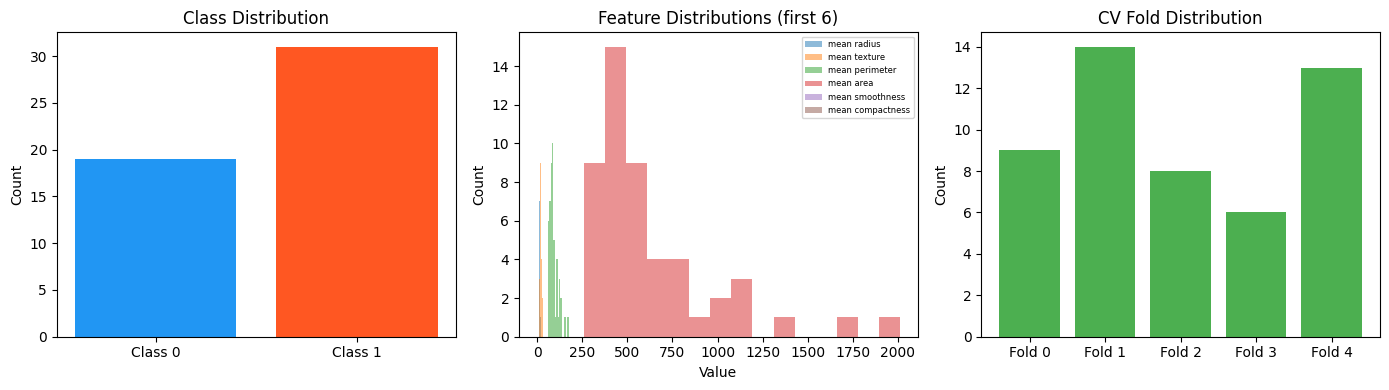

Saved: demo_visualization.png


In [11]:
# Parse demo data into arrays
demo_ds = data["datasets"][0]
demo_examples = demo_ds["examples"]
X_demo = np.array([json.loads(ex["input"]) for ex in demo_examples])
y_demo = np.array([int(ex["output"]) for ex in demo_examples])
feature_names = demo_examples[0].get("metadata_feature_names", [f"f{i}" for i in range(X_demo.shape[1])])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Class distribution
classes, counts = np.unique(y_demo, return_counts=True)
colors = ['#2196F3', '#FF5722']
axes[0].bar([f"Class {c}" for c in classes], counts, color=colors[:len(classes)])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

# Plot 2: Feature distributions (first 6 features)
n_show = min(6, X_demo.shape[1])
for i in range(n_show):
    axes[1].hist(X_demo[:, i], bins=15, alpha=0.5, label=feature_names[i])
axes[1].set_title(f"Feature Distributions (first {n_show})")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=6)

# Plot 3: Fold distribution
folds = [ex["metadata_fold"] for ex in demo_examples]
fold_ids, fold_counts = np.unique(folds, return_counts=True)
axes[2].bar([f"Fold {f}" for f in fold_ids], fold_counts, color='#4CAF50')
axes[2].set_title("CV Fold Distribution")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("demo_visualization.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: demo_visualization.png")